Question c

Processing first image...
ret found


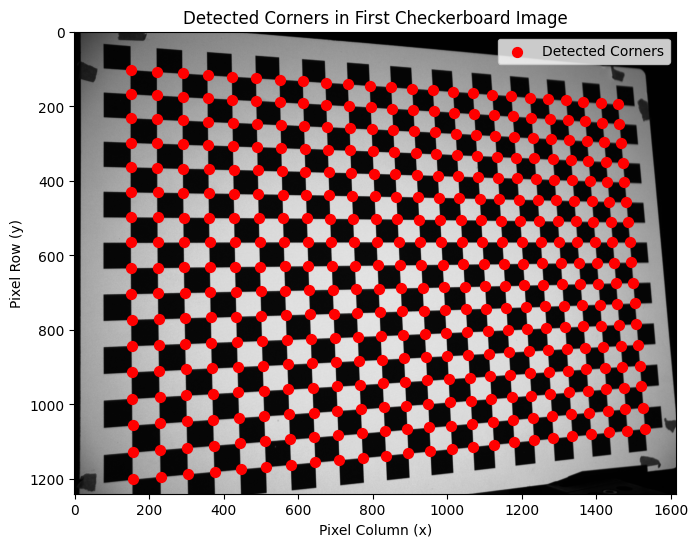

Corners successfully detected in the first image.

Processing all images...

Processing image 1: 1.png
ret found
Successfully detected 408 corners in image 1.

Processing image 2: 10.png
ret found
Successfully detected 408 corners in image 2.

Processing image 3: 11.png
ret found
Successfully detected 408 corners in image 3.

Processing image 4: 12.png
Failed to detect corners in image 4: 12.png

Processing image 5: 13.png
ret found
Successfully detected 408 corners in image 5.

Processing image 6: 14.png
ret found
Successfully detected 408 corners in image 6.

Processing image 7: 15.png
Failed to detect corners in image 7: 15.png

Processing image 8: 16.png
ret found
Successfully detected 408 corners in image 8.

Processing image 9: 17.png
ret found
Successfully detected 408 corners in image 9.

Processing image 10: 18.png
ret found
Successfully detected 408 corners in image 10.

Processing image 11: 19.png
Failed to detect corners in image 11: 19.png

Processing image 12: 2.png
ret f

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Define checkerboard size (number of inner corners per row and column)
CHECKERBOARD = (17, 24)  # Example: 9x6 inner corners

objp = np.zeros((17*24,3), np.float32)
objp[:,:2] = np.mgrid[0:17,0:24].T.reshape(-1,2)
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

# Directory containing the checkerboard images
DATA_DIR = "Data/Calibration/NoPattern"
image_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))  # Adjust extension if needed

# Function to detect and plot corners
def detect_and_plot_corners(image_path, plot_title, save_path=None):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return False, None, img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect checkerboard corners
    ret, corners=cv2.findChessboardCornersSB(gray, CHECKERBOARD, cv2.CALIB_CB_NORMALIZE_IMAGE,cv2.CALIB_CB_EXHAUSTIVE)

    if ret:
        print("ret found")
        objpoints.append(objp)
        # Refine corner positions
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001))
        imgpoints.append(corners)
        # Draw corners on image for visualization
        img_with_corners = img.copy()
        cv2.drawChessboardCorners(img_with_corners, CHECKERBOARD, corners, ret)

        # Plot corners in pixel coordinates
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        corners = corners.squeeze()  # Shape: (N, 2)
        plt.scatter(corners[:, 0], corners[:, 1], c='red', s=50, label='Detected Corners')
        plt.title(plot_title)
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        plt.legend()
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()

        return True, corners, img_with_corners
    else:
        # Plot the image even if detection failed
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"{plot_title} (No Corners Detected)")
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()
        return False, None, img

# Part a: Detect and plot corners for the first image
if image_files:
    print("Processing first image...")
    success, corners, _ = detect_and_plot_corners(
        image_files[0], 
        "Detected Corners in First Checkerboard Image"
    )
    if success:
        print("Corners successfully detected in the first image.")
    else:
        print("Failed to detect corners in the first image.")

# Part b: Detect corners in all 30 images and report failures
print("\nProcessing all images...")
failed_images = []
for i, img_path in enumerate(image_files[:30]):  # Limit to 30 images
    print(f"\nProcessing image {i+1}: {os.path.basename(img_path)}")
    save_path = f"output_image_{i+1}.png"
    success, corners, _ = detect_and_plot_corners(
        img_path, 
        f"Checkerboard Image {i+1}", 
        save_path=save_path
    )
    if not success:
        print(f"Failed to detect corners in image {i+1}: {os.path.basename(img_path)}")
        failed_images.append((i+1, img_path, save_path))
    else:
        print(f"Successfully detected {len(corners)} corners in image {i+1}.")

# Report summary
print("\nSummary:")
print(f"Processed {min(len(image_files), 30)} images.")
print(f"Number of images with failed corner detection: {len(failed_images)}")
if failed_images:
    print("Images with failed corner detection:")
    for idx, img_path, save_path in failed_images:
        print(f"Image {idx}: {os.path.basename(img_path)} (see {save_path})")
else:
    print("All corners successfully detected in all images.")

img = cv2.imread("Data/Calibration/NoPattern/1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
camera_width=img.shape[0]
camera_height=img.shape[1]
Number_of_Images=19
criteriaEnd = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001)  # Termination criteria for estimateCameraParams
reprojectionError1, camera_matrix1, dist_coeffs1, rotation_vectors, translation_vectors = cv2.calibrateCamera(
    objpoints, imgpoints, (camera_width, camera_height), None, None,
    flags=cv2.CALIB_FIX_K4 + cv2.CALIB_FIX_K5 + cv2.CALIB_FIX_K6,criteria=criteriaEnd
)
print(reprojectionError1)

In [52]:
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(camera_matrix1, 
                                                  dist_coeffs1, 
                                                  (camera_width,camera_height), 
                                                  1, 
                                                  (camera_width,camera_height)
                                                  )

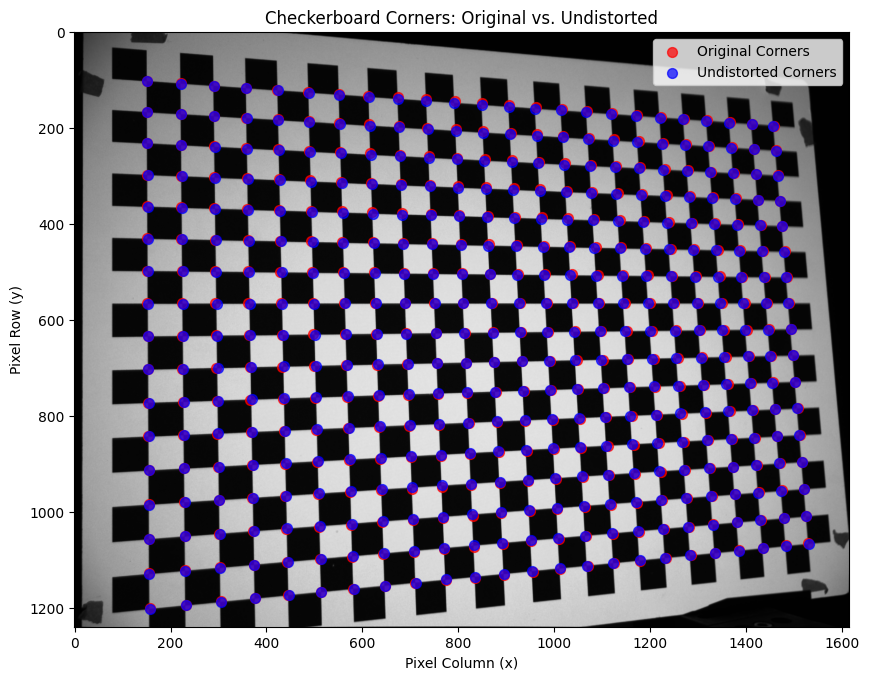

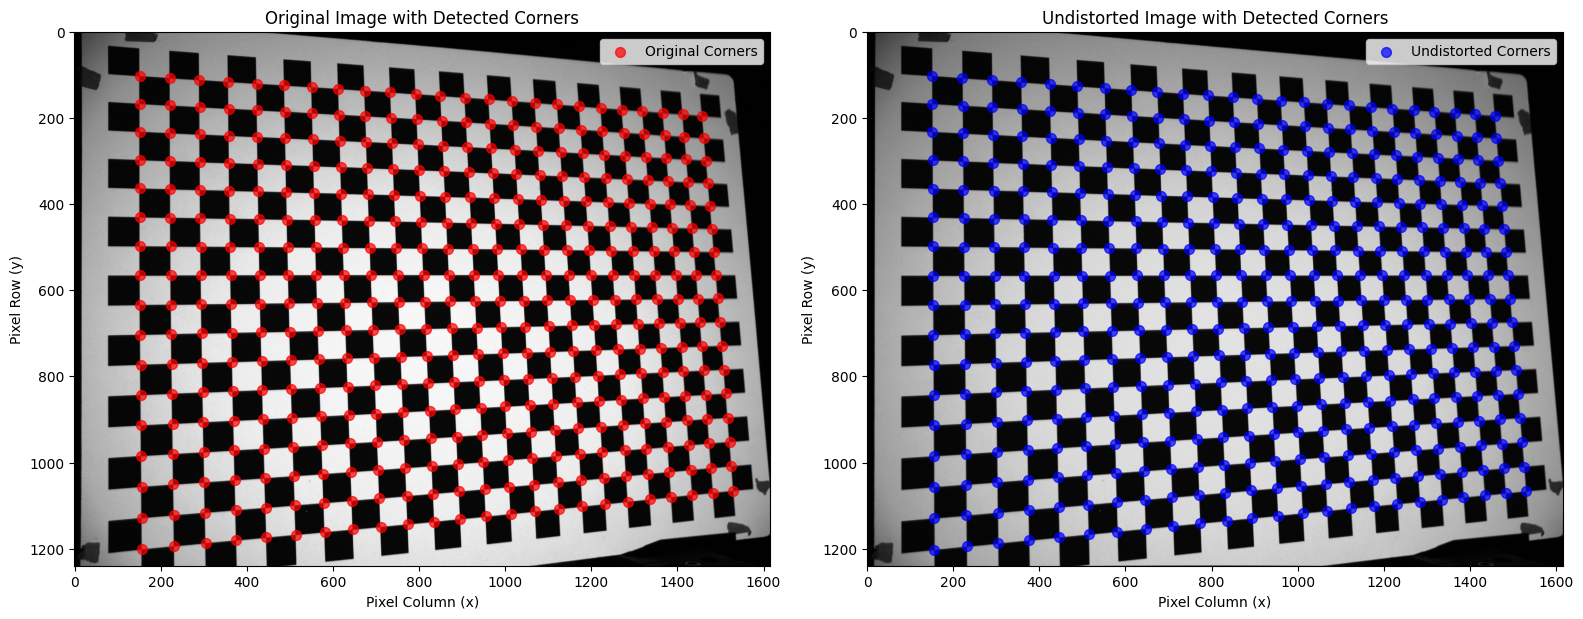

In [53]:
import cv2
import matplotlib.pyplot as plt
import numpy as np



# Load the image
img = cv2.imread("Data/Calibration/NoPattern/1.png")
if img is None:
    raise FileNotFoundError("Image not found: Data/Calibration/NoPattern/1.png")

# Convert to grayscale for corner detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect corners in the original (distorted) image
ret, corners_orig = cv2.findChessboardCornersSB(
    gray, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)
    corners_orig = cv2.cornerSubPix(gray, corners_orig, (11, 11), (-1, -1), criteria)
else:
    raise ValueError("Checkerboard corners not detected in original image")

# Undistort the image
un_dst_img = cv2.undistort(img, camera_matrix1, dist_coeffs1, None, newcameramtx)

# Convert undistorted image to grayscale for corner detection
un_dst_gray = cv2.cvtColor(un_dst_img, cv2.COLOR_BGR2GRAY)

# Detect corners in the undistorted image
ret, corners_undist = cv2.findChessboardCornersSB(
    un_dst_gray, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    corners_undist = cv2.cornerSubPix(un_dst_gray, corners_undist, (11, 11), (-1, -1), criteria)
else:
    raise ValueError("Checkerboard corners not detected in undistorted image")

# Convert undistorted image to RGB for plotting
un_dst_rgb = cv2.cvtColor(un_dst_img, cv2.COLOR_BGR2RGB)

# Plot the undistorted image with both sets of corners
plt.figure(figsize=(10, 8))
plt.imshow(un_dst_rgb)
# Plot original corners (red)
corners_orig = corners_orig.squeeze()  # Shape: (N, 2)
plt.scatter(corners_orig[:, 0], corners_orig[:, 1], c='red', s=50, label='Original Corners', alpha=0.7)
# Plot undistorted corners (blue)
corners_undist = corners_undist.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist[:, 0], corners_undist[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Checkerboard Corners: Original vs. Undistorted')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()
plt.show()
plt.close()

# Create side-by-side plots
plt.figure(figsize=(16, 6))

# Left subplot: Original image with original corners
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
corners_orig = corners_orig.squeeze()  # Shape: (N, 2)
plt.scatter(corners_orig[:, 0], corners_orig[:, 1], c='red', s=50, label='Original Corners', alpha=0.7)
plt.title('Original Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Right subplot: Undistorted image with undistorted corners
plt.subplot(1, 2, 2)
plt.imshow(un_dst_rgb)
corners_undist = corners_undist.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist[:, 0], corners_undist[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Undistorted Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()
plt.close()

Question D

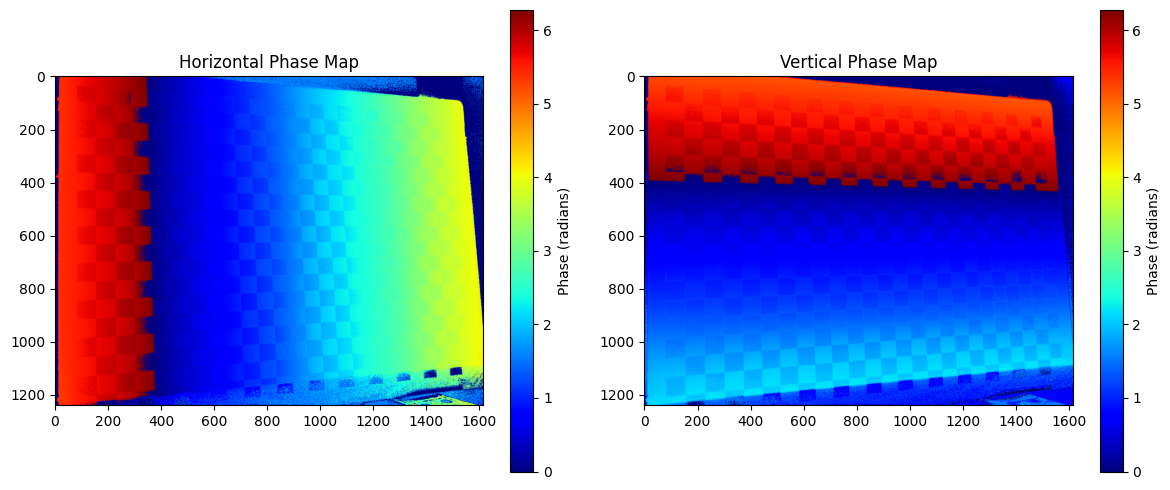

Camera-Projector Correspondence (first 5 corners):
Corner 0: Camera (156.40, 1202.06) -> Projector (3495.73, 1267.32)
Corner 1: Camera (155.97, 1129.18) -> Projector (3501.71, 1168.39)
Corner 2: Camera (155.62, 1056.64) -> Projector (3495.14, 1051.69)
Corner 3: Camera (155.34, 984.82) -> Projector (3492.06, 936.95)
Corner 4: Camera (154.99, 913.45) -> Projector (3501.23, 816.74)
Corner 5: Camera (154.61, 842.79) -> Projector (3495.19, 718.07)
Corner 6: Camera (154.36, 772.54) -> Projector (3512.33, 615.39)
Corner 7: Camera (153.96, 703.05) -> Projector (3503.95, 503.80)
Corner 8: Camera (153.59, 634.01) -> Projector (3515.96, 356.03)
Corner 9: Camera (153.28, 565.77) -> Projector (3499.65, 274.41)
Corner 10: Camera (152.93, 497.92) -> Projector (3507.63, 168.33)
Corner 11: Camera (152.58, 430.50) -> Projector (3513.06, 49.44)
Corner 12: Camera (152.38, 363.79) -> Projector (3519.27, 3778.06)
Corner 13: Camera (152.06, 297.61) -> Projector (3507.51, 3663.21)
Corner 14: Camera (151.65, 2

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Projector resolution
PROJ_COLS = 3840  # Columns
PROJ_ROWS = 2160  # Rows

# Phase ranges
HORIZ_PHASE_RANGE = 2 * np.pi  # [0, 2π] for horizontal (columns)
VERT_PHASE_RANGE = 1.125 * np.pi  # [0, 1.125π] for vertical (rows)

# Checkerboard size (inner corners, adjust as needed)
CHECKERBOARD = (17, 24)

def compute_phase_map(I0, I1, I2, I3):
    """
    Compute phase map using four-phase shift algorithm.
    I0, I1, I2, I3: Grayscale images with phase shifts 0, π/2, π, 3π/2.
    Returns: Phase map in radians.
    """
    # Ensure images are float for calculations
    I0 = I0.astype(float)
    I1 = I1.astype(float)
    I2 = I2.astype(float)
    I3 = I3.astype(float)
    
    # Four-phase shift formula: φ = atan2(I3 - I1, I0 - I2)
    numerator = I3 - I1
    denominator = I0 - I2
    # Avoid division by zero
    phase = np.arctan2(numerator, denominator)  # Phase in [-π, π]
    # Unwrap phase to [0, 2π]
    phase = np.where(phase < 0, phase + 2 * np.pi, phase)
    return phase

def load_phase_images(base_path, pos_num="pos1"):
    """
    Load eight phase-shifted images: 1-4 (horizontal), 5-8 (vertical).
    base_path: Directory path (e.g., 'Data/Calibration/NoPattern').
    Returns: Two tuples of four grayscale images (horizontal: I0-I3, vertical: I0-I3).
    """
    # Horizontal fringes: suffixes 1, 2, 3, 4
    h_I0 = cv2.imread(f"{base_path}/{pos_num}_1.png", cv2.IMREAD_GRAYSCALE)
    h_I1 = cv2.imread(f"{base_path}/{pos_num}_2.png", cv2.IMREAD_GRAYSCALE)
    h_I2 = cv2.imread(f"{base_path}/{pos_num}_3.png", cv2.IMREAD_GRAYSCALE)
    h_I3 = cv2.imread(f"{base_path}/{pos_num}_4.png", cv2.IMREAD_GRAYSCALE)
    
    # Vertical fringes: suffixes 5, 6, 7, 8
    v_I0 = cv2.imread(f"{base_path}/{pos_num}_5.png", cv2.IMREAD_GRAYSCALE)
    v_I1 = cv2.imread(f"{base_path}/{pos_num}_6.png", cv2.IMREAD_GRAYSCALE)
    v_I2 = cv2.imread(f"{base_path}/{pos_num}_7.png", cv2.IMREAD_GRAYSCALE)
    v_I3 = cv2.imread(f"{base_path}/{pos_num}_8.png", cv2.IMREAD_GRAYSCALE)
    
    # Check for missing images
    if any(img is None for img in [h_I0, h_I1, h_I2, h_I3, v_I0, v_I1, v_I2, v_I3]):
        raise FileNotFoundError(f"Failed to load phase images from {base_path}")
    
    return (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3)

def phase_to_projector_coords(phase_h, phase_v):
    """
    Convert phase values to projector coordinates.
    phase_h: Horizontal phase map [0, 2π].
    phase_v: Vertical phase map [0, 1.125π].
    Returns: Projector columns [0, 3840], rows [0, 2160].
    """
    # Normalize phase to projector coordinates
    proj_cols = (phase_h / HORIZ_PHASE_RANGE) * PROJ_COLS  # [0, 3840]
    proj_rows = (phase_v / VERT_PHASE_RANGE) * PROJ_ROWS  # [0, 2160]
    return proj_cols, proj_rows

def main():
    # Base path for images (adjust as needed)
    base_path_no_pattern = "Data/Calibration/NoPattern"
    base_path_pattern = "Data/Calibration/Patterns"
    
    # Load checkerboard image
    checker_img = cv2.imread(f"{base_path_no_pattern}/1.png")
    if checker_img is None:
        raise FileNotFoundError("Checkerboard image not found")
    
    # Undistort checkerboard image
    checker_undist = cv2.undistort(checker_img, camera_matrix1, dist_coeffs1, None, newcameramtx)
    gray_undist = cv2.cvtColor(checker_undist, cv2.COLOR_BGR2GRAY)
    
    # Detect checkerboard corners
    ret, corners = cv2.findChessboardCornersSB(
        gray_undist, CHECKERBOARD,
        flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
    )
    if not ret:
        raise ValueError("Checkerboard corners not detected")
    
    # Refine corners
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)
    corners = cv2.cornerSubPix(gray_undist, corners, (11, 11), (-1, -1), criteria)
    corners = corners.squeeze()  # Shape: (N, 2)
    
    # Load phase-shifted images
    (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3) = load_phase_images(base_path_pattern)
    
    # Undistort phase images
    h_I0 = cv2.undistort(h_I0, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I1 = cv2.undistort(h_I1, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I2 = cv2.undistort(h_I2, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I3 = cv2.undistort(h_I3, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I0 = cv2.undistort(v_I0, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I1 = cv2.undistort(v_I1, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I2 = cv2.undistort(v_I2, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I3 = cv2.undistort(v_I3, camera_matrix1, dist_coeffs1, None, newcameramtx)
    
    # Compute phase maps
    phase_h = compute_phase_map(h_I0, h_I1, h_I2, h_I3)  # Horizontal phase [0, 2π]
    phase_v = compute_phase_map(v_I0, v_I1, v_I2, v_I3)  # Vertical phase [0, 1.125π]
    
    
    # Extract phase at checkerboard corners
    corner_phases_h = []
    corner_phases_v = []
    for corner in corners:
        x, y = int(corner[0]), int(corner[1])  # Pixel coordinates
        corner_phases_h.append(phase_h[y, x])
        corner_phases_v.append(phase_v[y, x])
    corner_phases_h = np.array(corner_phases_h)
    corner_phases_v = np.array(corner_phases_v)
    
    # Convert phase to projector coordinates
    proj_cols, proj_rows = phase_to_projector_coords(corner_phases_h, corner_phases_v)
    
    # Store camera-projector correspondence
    correspondence = []
    for i, corner in enumerate(corners):
        cam_x, cam_y = corner  # Camera pixel coordinates
        proj_col, proj_row = proj_cols[i], proj_rows[i]  # Projector coordinates
        correspondence.append({
            'camera': (cam_x, cam_y),
            'projector': (proj_col, proj_row)
        })
    
    # Visualize phase maps (optional)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(phase_h, cmap='jet')
    plt.title('Horizontal Phase Map')
    plt.colorbar(label='Phase (radians)')
    plt.subplot(1, 2, 2)
    plt.imshow(phase_v, cmap='jet')
    plt.title('Vertical Phase Map')
    plt.colorbar(label='Phase (radians)')
    plt.tight_layout()
    plt.show()
    
    # Print correspondence for the first few corners
    print("Camera-Projector Correspondence (first 5 corners):")
    for i, corr in enumerate(correspondence[:]):
        print(f"Corner {i}: Camera ({corr['camera'][0]:.2f}, {corr['camera'][1]:.2f}) "
              f"-> Projector ({corr['projector'][0]:.2f}, {corr['projector'][1]:.2f})")
    
    return correspondence

if __name__ == "__main__":
    correspondence = main()